<div style="width: 100%; clear: both;">
  <div style="float: left; width: 50%;">
    <img src="https://www.ucc.edu.co/institucional/acerca-de-la-universidad/Documents/logo_ucc_2018(CURVAS)-01.png" align="left" style="max-width: 100%; height: auto;">
  </div>
  <div style="float: right; width: 50%;">
    <p style="margin: 0; padding-top: 22px; text-align:right;"><strong>Laboratorio de Tecnologías Emergentes</strong></p>
    <p style="margin: 0; text-align:right;"><strong>Línea de Inteligencia Artificial</strong></p>
    <p style="margin: 0; text-align:right;">Universidad Cooperativa de Colombia, Campus Ibagué-Espinal</p>
    <p style="margin: 0; text-align:right;">Facultad de Ingeniería</p>
    <p style="margin: 0; text-align:right; padding-bottom: 100px;">Programa de Ingeniería de Sistemas</p>
  </div>
</div>
<div style="width:100%;">&nbsp;</div>
<div style="font-size: 20px; font-weight: bold; background: linear-gradient(to right, #ff7e5f, #feb47b); -webkit-background-clip: text; color: grey; text-align: center">W&F BirdLab — Taller: Domando a la IA</div>

# Laboratorio: "Domando a la IA" — Técnicas contra el Sobreajuste

**Contexto:** Un modelo sobreajustado es como un estudiante que memoriza el libro pero no entiende el tema.  
Si le preguntas algo diferente a lo que memorizó, falla. En este taller aplicaremos **4 niveles de mejora** 
a nuestro clasificador de aves, partiendo siempre de la misma arquitectura base (MobileNetV3-Large, backbone congelado).

### Estructura del taller

| Nivel | Técnica | ¿Qué resuelve? |
|-------|---------|----------------|
| **0 — Línea base** | Sin ajustes | Referencia de partida |
| **1 — Dropout** | Apaga neuronas al azar | Memorización excesiva |
| **2 — Early Stopping** | Detiene el entrenamiento antes | Entrenamiento excesivo |
| **3 — LR Decay** | Reduce el paso de aprendizaje | Curvas ruidosas / zig-zag |
| **4 — Validación** | Curvas + Matriz de confusión | Ver el impacto acumulado |

> **Metodología:** cada nivel se construye sobre el anterior. Al final compararemos los 4 resultados
> en una tabla para evidenciar cómo cada técnica impacta el rendimiento.


## 1. Preparación del Entorno

In [1]:
# !pip install torch torchvision scikit-learn seaborn

import torch
import torch.nn as nn
import torchvision
import torchvision.models as models
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from pathlib import Path
import json, time, copy
from datetime import datetime

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} | Dispositivo: {device}")


/home/walter/miniconda3/envs/aves/lib/python3.10/site-packages/numpy/_core/getlimits.py:551: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


PyTorch 2.11.0+cu130 | Dispositivo: cpu


## 2. Hiperparámetros Compartidos

In [6]:
IMAGE_SIZE  = 224
BATCH_SIZE  = 32
NUM_EPOCHS  = 30      
LR          = 1e-3    

DATASET_ROOT = Path("../data/split")
TRAIN_DIR    = DATASET_ROOT / "train"
VAL_DIR      = DATASET_ROOT / "val"
LOG_DIR      = Path("../logs/taller")
CKPT_DIR     = Path("../src/models/checkpoints/pro")
LOG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Épocas: {NUM_EPOCHS} | Batch: {BATCH_SIZE} | LR: {LR}")
print(f"Dataset: {DATASET_ROOT}")
print(f"Checkpoints → {CKPT_DIR}")


Épocas: 30 | Batch: 32 | LR: 0.001
Dataset: ../data/split
Checkpoints → ../src/models/checkpoints/pro


## 3. Carga de Datos

Las transformaciones son iguales para todos los niveles. El único elemento que cambia
entre niveles es la **arquitectura del clasificador** y los **parámetros de entrenamiento**.


In [3]:
TRAIN_TRANSFORM = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

EVAL_TRANSFORM = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

train_ds = ImageFolder(root=str(TRAIN_DIR), transform=TRAIN_TRANSFORM)
val_ds   = ImageFolder(root=str(VAL_DIR),   transform=EVAL_TRANSFORM)

classes     = train_ds.classes
num_classes = len(classes)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Especies ({num_classes}):")
for i, c in enumerate(classes):
    print(f"  [{i:02d}] {c}")
print(f"\nImágenes — Train: {len(train_ds)} | Val: {len(val_ds)}")


Especies (16):
  [00] ardea-alba
  [01] atlapetes-latinuchus
  [02] butorides-striata
  [03] chlorochrysa-nitidissima
  [04] colibri-coruscans
  [05] common-gallinule
  [06] metallura-tyrianthina
  [07] momotus-aequatorialis
  [08] phimosus-infuscatus
  [09] piaya-cayana
  [10] pitangus-sulphuratus
  [11] ramphastos-ambiguus
  [12] sicalis-flaveola
  [13] thraupis-episcopus
  [14] turdus-fuscater
  [15] zenaida-auriculata

Imágenes — Train: 1046 | Val: 204


## 4. Funciones de Entrenamiento y Validación (compartidas)

In [4]:
def run_epoch(model, loader, criterion, optimizer=None):
    """Un paso de entrenamiento o validación."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(is_train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if is_train:
                optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            if is_train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct    += (out.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total


def build_base_model(num_classes: int, dropout: float = 0.0) -> nn.Module:
    """
    Construye MobileNetV3-Small con backbone congelado.
    dropout=0.0  → sin Dropout (Nivel 0)
    dropout=0.5  → con Dropout al 50% (Nivel 1 en adelante)
    """
    m = models.mobilenet_v3_small(
        weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
    )
    for param in m.parameters():
        param.requires_grad = False          # congelar backbone

    in_features = m.classifier[3].in_features

    if dropout > 0:
        m.classifier[3] = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, num_classes),
        )
    else:
        m.classifier[3] = nn.Linear(in_features, num_classes)

    return m.to(device)


def plot_curves(history: list, title: str, save_path=None):
    """Curvas de accuracy y loss con área de gap resaltada."""
    epochs      = [r["epoch"]      for r in history]
    train_accs  = [r["train_acc"]  for r in history]
    val_accs    = [r["val_acc"]    for r in history]
    train_losses= [r["train_loss"] for r in history]
    val_losses  = [r["val_loss"]   for r in history]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    ax = axes[0]
    ax.plot(epochs, train_accs,  "o-", ms=4, label="Train Accuracy")
    ax.plot(epochs, val_accs,    "s-", ms=4, label="Val Accuracy")
    ax.fill_between(epochs, train_accs, val_accs,
                    where=[t > v for t, v in zip(train_accs, val_accs)],
                    alpha=0.13, color="red", label="Brecha (overfitting)")
    ax.set_title("Precisión (Accuracy)")
    ax.set_xlabel("Época"); ax.set_ylabel("Exactitud")
    ax.set_ylim(0, 1.05); ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.plot(epochs, train_losses, "o-", ms=4, label="Train Loss")
    ax.plot(epochs, val_losses,   "s-", ms=4, label="Val Loss")
    ax.fill_between(epochs, val_losses, train_losses,
                    where=[v > t for v, t in zip(val_losses, train_losses)],
                    alpha=0.13, color="orange", label="Val > Train")
    ax.set_title("Pérdida (Loss)")
    ax.set_xlabel("Época"); ax.set_ylabel("Pérdida")
    ax.legend(); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def plot_confusion_matrix(model, loader, classes, title, save_path=None):
    """Matriz de confusión del modelo sobre el loader dado."""
    all_preds, all_labels = [], []
    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            preds = model(imgs).argmax(1)
            all_preds.append(preds.cpu())
            all_labels.append(labels)
    y_pred = torch.cat(all_preds).numpy()
    y_true = torch.cat(all_labels).numpy()

    cm = confusion_matrix(y_true, y_pred)
    acc = (y_pred == y_true).mean()

    fig, ax = plt.subplots(figsize=(13, 11))
    ConfusionMatrixDisplay(cm, display_labels=classes).plot(
        ax=ax, cmap="Blues", colorbar=True, xticks_rotation=45
    )
    ax.set_title(f"{title}\nVal Accuracy: {acc*100:.2f}%",
                 fontsize=12, fontweight="bold", pad=12)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    return y_true, y_pred, acc


print("OK Funciones utilitarias cargadas.")


OK Funciones utilitarias cargadas.


---
## Nivel 0 — Línea Base 

Antes de aplicar cualquier técnica, entrenamos el modelo **tal cual**, sin ningún ajuste.
Este resultado es nuestra referencia. Todo lo que venga después debe compararse contra estos números.

**¿Qué buscar en las gráficas?**
- Si la curva de **Loss de entrenamiento** baja pero la de **validación** sube o se estanca → **Gap de Sobreajuste**
- Si ambas son bajas desde el inicio → **Underfitting** (el modelo no aprende nada)
- Picos o zig-zags → el **Learning Rate** puede estar demasiado alto


In [7]:
# ── Nivel 0: sin Dropout, sin Early Stop, sin LR Decay ──────────
model_n0  = build_base_model(num_classes, dropout=0.0)
optim_n0  = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_n0.parameters()), lr=LR
)
criterion = nn.CrossEntropyLoss()
history_n0 = []

print("Entrenando Nivel 0 (línea base)...")
print(f"{'Época':>6}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>9}  {'Val Acc':>8}")
print("-" * 52)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    tl, ta = run_epoch(model_n0, train_loader, criterion, optim_n0)
    vl, va = run_epoch(model_n0, val_loader,   criterion, None)
    history_n0.append({
        "epoch": epoch, "train_loss": round(tl,4), "train_acc": round(ta,4),
        "val_loss": round(vl,4), "val_acc": round(va,4)
    })
    print(f"{epoch:>6}  {tl:>10.4f}  {ta:>9.4f}  {vl:>9.4f}  {va:>8.4f}")

print(f"\nOK Nivel 0 completado.")


Entrenando Nivel 0 (línea base)...
 Época  Train Loss  Train Acc   Val Loss   Val Acc
----------------------------------------------------


/home/walter/miniconda3/envs/aves/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


     1      2.1659     0.4895     1.1797    0.7990
     2      1.2050     0.8222     0.6775    0.8578
     3      0.7877     0.8929     0.5164    0.9020
     4      0.6131     0.9130     0.4310    0.9167
     5      0.4923     0.9302     0.3945    0.9412
     6      0.4198     0.9388     0.3663    0.9363
     7      0.3677     0.9436     0.3460    0.9461
     8      0.3096     0.9685     0.3322    0.9412
     9      0.2845     0.9570     0.3173    0.9412
    10      0.2541     0.9637     0.3076    0.9412
    11      0.2446     0.9627     0.2975    0.9461
    12      0.2212     0.9685     0.2831    0.9461
    13      0.2090     0.9704     0.2761    0.9461
    14      0.1839     0.9780     0.2667    0.9461
    15      0.1972     0.9608     0.2601    0.9461
    16      0.1536     0.9751     0.2533    0.9510
    17      0.1603     0.9799     0.2470    0.9461
    18      0.1485     0.9751     0.2453    0.9412
    19      0.1451     0.9780     0.2437    0.9510
    20      0.1410     0.9876  

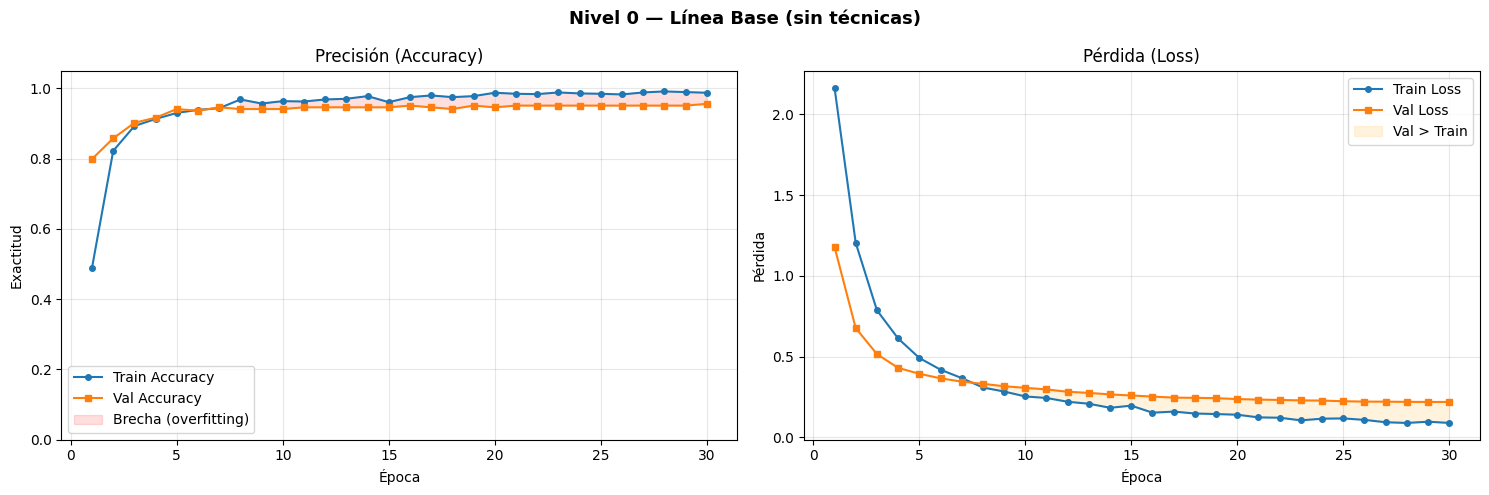

In [8]:
plot_curves(history_n0,
            "Nivel 0 — Línea Base (sin técnicas)",
            save_path=LOG_DIR / "n0_curvas.png")


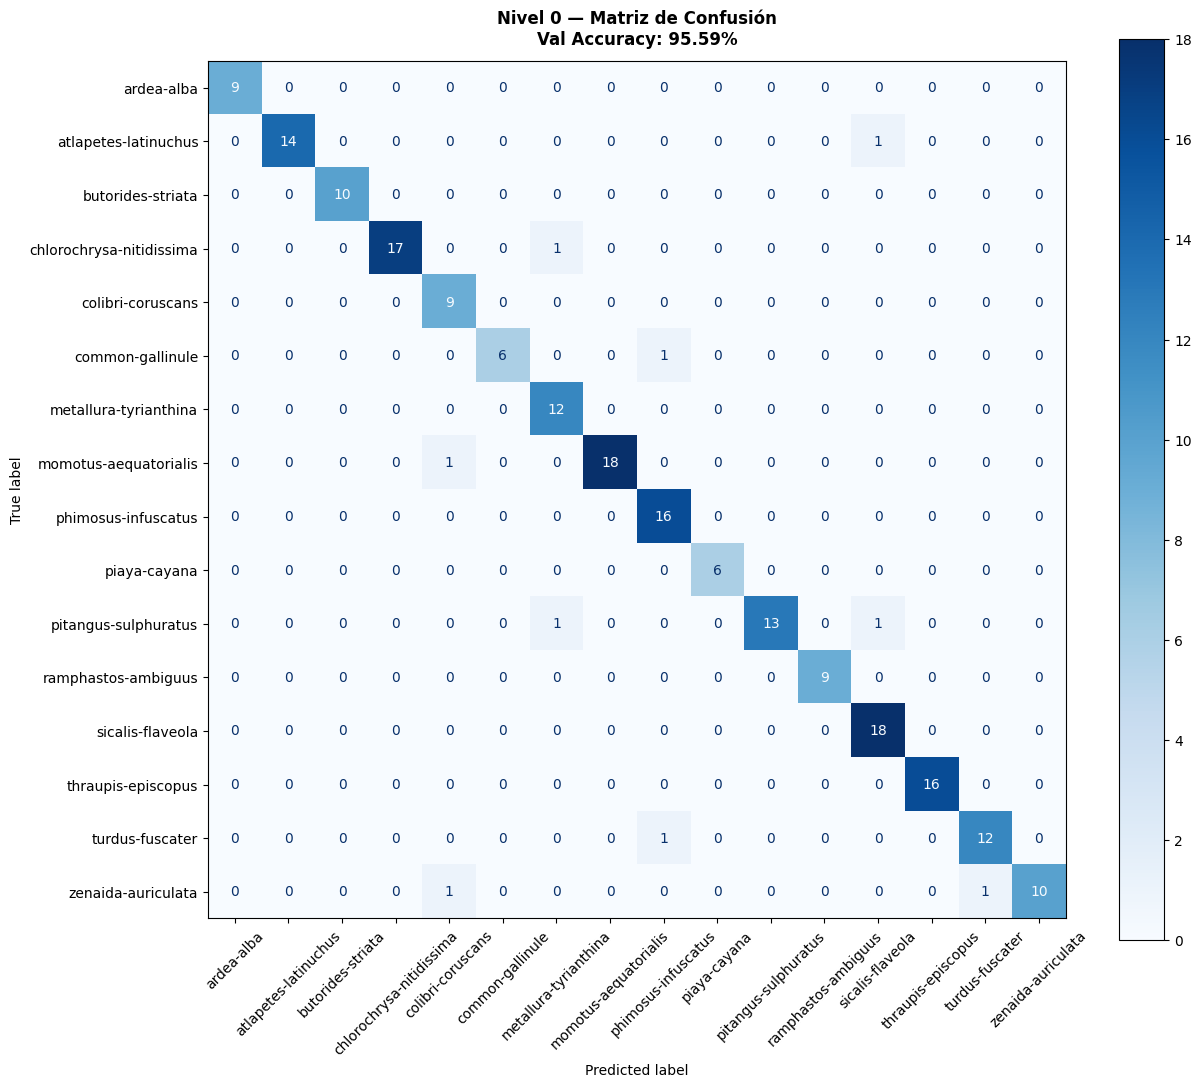

Val Accuracy Nivel 0: 0.9559


In [9]:
_, _, acc_n0 = plot_confusion_matrix(
    model_n0, val_loader, classes,
    "Nivel 0 — Matriz de Confusión",
    save_path=LOG_DIR / "n0_confusion.png"
)
print(f"Val Accuracy Nivel 0: {acc_n0:.4f}")


---
## Nivel 1 — Dropout (Regularización por Abandono) 

### ¿Qué es el Dropout?

Durante cada paso de entrenamiento, **apagamos aleatoriamente el 50% de las neuronas** del clasificador.
Una neurona "apagada" no contribuye al resultado ni recibe gradientes en ese paso.

```
Sin Dropout:   [N1]→[N2]→[N3]→[N4] → salida
Con Dropout:   [N1]→[  ]→[N3]→[  ] → salida  (N2 y N4 apagadas en este paso)
               [N1]→[N2]→[  ]→[N4] → salida  (N3 apagada en el siguiente)
```

**¿Por qué reduce el sobreajuste?**  
Ninguna neurona puede volverse "indispensable" para memorizar un patrón específico.
La red aprende representaciones distribuidas y más robustas.

> [!] El Dropout **solo se activa durante el entrenamiento**. En validación y test
> todas las neuronas están activas (`model.eval()` lo maneja automáticamente).


In [10]:
# ── Nivel 1: Dropout 50%, sin Early Stop, sin LR Decay ──────────
model_n1 = build_base_model(num_classes, dropout=0.5)
optim_n1 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_n1.parameters()), lr=LR
)
history_n1 = []

print("Entrenando Nivel 1 (Dropout 50%)...")
print(f"{'Época':>6}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>9}  {'Val Acc':>8}")
print("-" * 52)

for epoch in range(1, NUM_EPOCHS + 1):
    tl, ta = run_epoch(model_n1, train_loader, criterion, optim_n1)
    vl, va = run_epoch(model_n1, val_loader,   criterion, None)
    history_n1.append({
        "epoch": epoch, "train_loss": round(tl,4), "train_acc": round(ta,4),
        "val_loss": round(vl,4), "val_acc": round(va,4)
    })
    print(f"{epoch:>6}  {tl:>10.4f}  {ta:>9.4f}  {vl:>9.4f}  {va:>8.4f}")

print(f"\nOK Nivel 1 completado.")


Entrenando Nivel 1 (Dropout 50%)...
 Época  Train Loss  Train Acc   Val Loss   Val Acc
----------------------------------------------------


/home/walter/miniconda3/envs/aves/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


     1      2.3362     0.3489     1.4612    0.7206
     2      1.4617     0.7400     0.8907    0.8431
     3      1.0547     0.8250     0.6661    0.8775
     4      0.8433     0.8509     0.5660    0.9020
     5      0.7141     0.8767     0.5060    0.9167
     6      0.5903     0.9015     0.4681    0.9216
     7      0.5548     0.8862     0.4449    0.9216
     8      0.4685     0.9197     0.4168    0.9265
     9      0.4444     0.9254     0.3950    0.9363
    10      0.3972     0.9283     0.3751    0.9363
    11      0.3855     0.9226     0.3624    0.9412
    12      0.3561     0.9293     0.3513    0.9461
    13      0.3510     0.9293     0.3354    0.9461
    14      0.3363     0.9331     0.3250    0.9412
    15      0.2968     0.9436     0.3141    0.9412
    16      0.2923     0.9465     0.3074    0.9412
    17      0.2697     0.9551     0.2991    0.9363
    18      0.2838     0.9331     0.2926    0.9412
    19      0.2638     0.9417     0.2850    0.9412
    20      0.2698     0.9436  

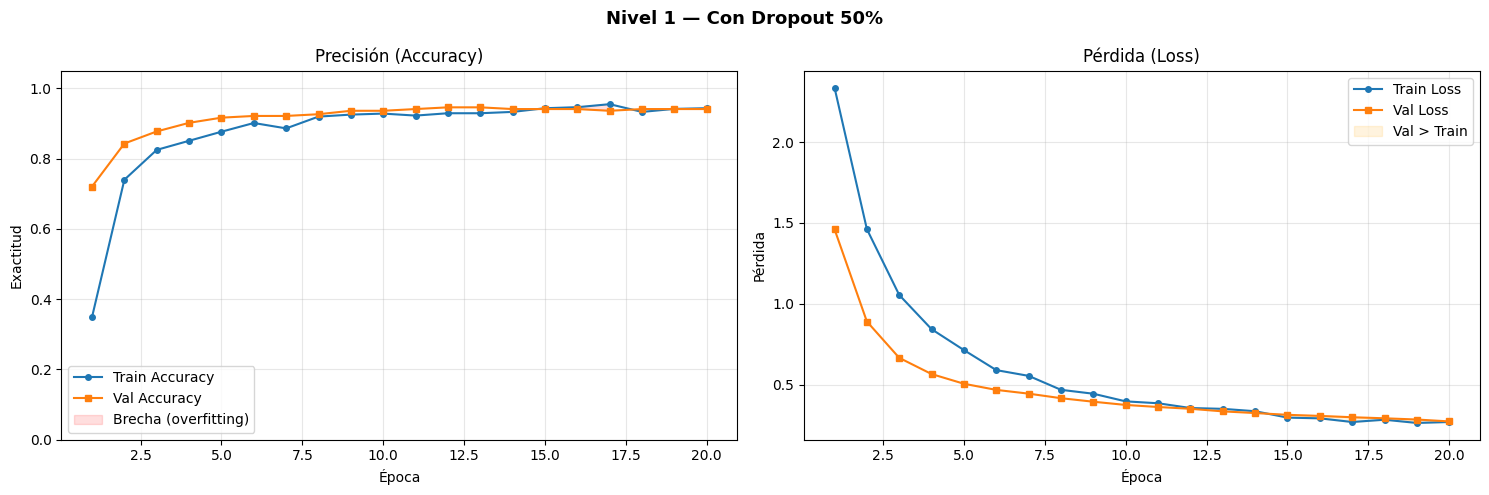

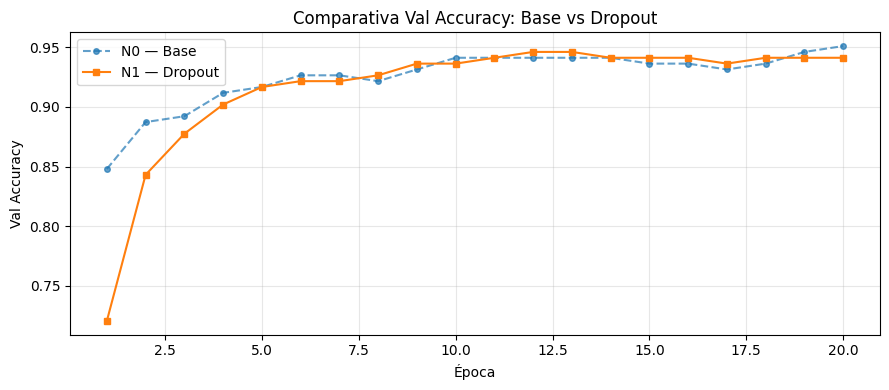

In [11]:
plot_curves(history_n1,
            "Nivel 1 — Con Dropout 50%",
            save_path=LOG_DIR / "n1_curvas.png")

# Comparativa rápida con línea base
fig, ax = plt.subplots(figsize=(9, 4))
e0 = [r["epoch"]   for r in history_n0]
e1 = [r["epoch"]   for r in history_n1]
ax.plot(e0, [r["val_acc"] for r in history_n0], "o--", ms=4, label="N0 — Base", alpha=0.7)
ax.plot(e1, [r["val_acc"] for r in history_n1], "s-",  ms=4, label="N1 — Dropout")
ax.set_title("Comparativa Val Accuracy: Base vs Dropout")
ax.set_xlabel("Época"); ax.set_ylabel("Val Accuracy")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(LOG_DIR / "n1_vs_n0.png", dpi=150, bbox_inches="tight")
plt.show()


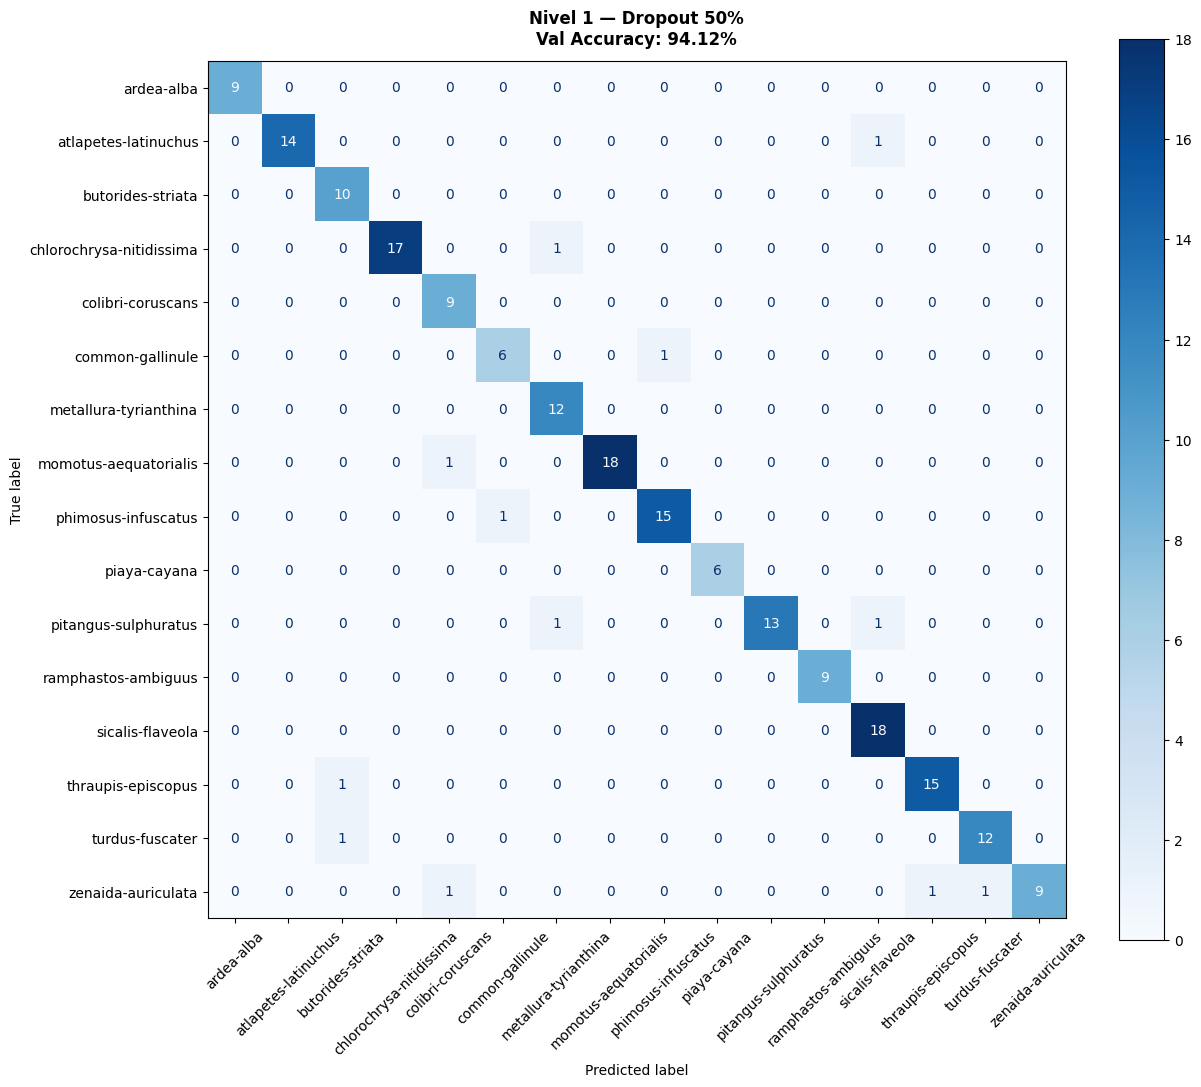


  PREGUNTA 1: ¿Mejoró el gap con Dropout?
  Gap N0 (base):    +0.0299  (train-val accuracy)
  Gap N1 (dropout): +0.0024
  Reducción del gap: +0.0275

  [OK] SÍ mejoró: el gap se redujo con Dropout.
     El modelo depende menos de patrones memoriza dos.


In [12]:
_, _, acc_n1 = plot_confusion_matrix(
    model_n1, val_loader, classes,
    "Nivel 1 — Dropout 50%",
    save_path=LOG_DIR / "n1_confusion.png"
)

# ── Pregunta del taller ─────────────────────────────────────────
gap_n0 = history_n0[-1]["train_acc"] - history_n0[-1]["val_acc"]
gap_n1 = history_n1[-1]["train_acc"] - history_n1[-1]["val_acc"]

print(f"\n{'='*55}")
print("  PREGUNTA 1: ¿Mejoró el gap con Dropout?")
print(f"{'='*55}")
print(f"  Gap N0 (base):    {gap_n0:+.4f}  (train-val accuracy)")
print(f"  Gap N1 (dropout): {gap_n1:+.4f}")
print(f"  Reducción del gap: {gap_n0 - gap_n1:+.4f}")
if gap_n1 < gap_n0:
    print("\n  [OK] SÍ mejoró: el gap se redujo con Dropout.")
    print("     El modelo depende menos de patrones memoriza dos.")
else:
    print("\n  [!]  El gap no mejoró significativamente.")
    print("     Puede que el overfitting sea leve o que se necesite más Dropout.")
print(f"{'='*55}")


---
## Nivel 2 — Early Stopping solo

### ¿Qué es el Early Stopping?

Monitoreamos la `val_loss` en cada época. Si no mejora durante `patience` épocas
consecutivas, detenemos el entrenamiento y **restauramos los pesos de la mejor época**.

```
Epoca 12: val_loss = 0.45  <- mejor, guardar pesos
Epoca 13: val_loss = 0.47  (no mejoro, contador = 1)
Epoca 14: val_loss = 0.49  (no mejoro, contador = 2)
Epoca 15: val_loss = 0.51  (no mejoro, contador = 3)
-> patience=3 -> DETENER. Restaurar pesos de epoca 12.
```

**¿Por qué funciona?**
Evita que el modelo "se pase" del punto optimo y empiece a memorizar.

> En este nivel el LR se mantiene **fijo** en `1e-3` durante todo el entrenamiento.
> Esto nos permite ver el efecto del Early Stopping de forma aislada,
> sin que el LR Decay enmascare o amplifique el resultado.


In [14]:
# ── Nivel 2: Dropout + Early Stopping (sin LR Decay) ─────────────
PATIENCE_ES = 5    # epocas sin mejora antes de detener

model_n2  = build_base_model(num_classes, dropout=0.5)
optim_n2  = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_n2.parameters()), lr=LR
)

history_n2    = []
best_val_loss = float("inf")
best_weights  = None
es_counter    = 0
stopped_epoch_n2 = NUM_EPOCHS

print("Entrenando Nivel 2 (Dropout + Early Stopping, LR fijo)...")
print(f"  patience={PATIENCE_ES} | LR={LR} (fijo, sin decay)")
print()
print(f"{'Epoca':>6}  {'Train Acc':>9}  {'Val Acc':>8}  {'Val Loss':>9}  {'ES':>6}")
print("-" * 48)

for epoch in range(1, NUM_EPOCHS + 1):
    tl, ta = run_epoch(model_n2, train_loader, criterion, optim_n2)
    vl, va = run_epoch(model_n2, val_loader,   criterion, None)

    if vl < best_val_loss:
        best_val_loss = vl
        best_weights  = copy.deepcopy(model_n2.state_dict())
        es_counter    = 0
        es_marker     = "[*]"
    else:
        es_counter += 1
        es_marker   = f"{es_counter}/{PATIENCE_ES}"

    history_n2.append({
        "epoch": epoch, "train_loss": round(tl,4), "train_acc": round(ta,4),
        "val_loss": round(vl,4), "val_acc": round(va,4),
    })
    print(f"{epoch:>6}  {ta:>9.4f}  {va:>8.4f}  {vl:>9.4f}  {es_marker:>6}")

    if es_counter >= PATIENCE_ES:
        stopped_epoch_n2 = epoch
        print(f"\n  [STOP] Early Stopping en epoca {epoch}.")
        print(f"         Restaurando pesos de la mejor epoca.")
        model_n2.load_state_dict(best_weights)
        break

if stopped_epoch_n2 == NUM_EPOCHS:
    print(f"\n  [i] Completo las {NUM_EPOCHS} epocas sin activar Early Stopping.")

print(f"\nOK Nivel 2 completado. Parado en epoca {stopped_epoch_n2}.")


Entrenando Nivel 2 (Dropout + Early Stopping, LR fijo)...
  patience=5 | LR=0.001 (fijo, sin decay)

 Epoca  Train Acc   Val Acc   Val Loss      ES
------------------------------------------------


/home/walter/miniconda3/envs/aves/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


     1     0.3738    0.7451     1.4687     [*]
     2     0.7180    0.8480     0.9054     [*]
     3     0.8155    0.8824     0.6782     [*]
     4     0.8595    0.9069     0.5659     [*]
     5     0.8987    0.9167     0.5039     [*]
     6     0.8948    0.9216     0.4631     [*]
     7     0.9168    0.9216     0.4293     [*]
     8     0.9130    0.9167     0.4062     [*]
     9     0.9216    0.9118     0.3889     [*]
    10     0.9149    0.9314     0.3725     [*]
    11     0.9197    0.9314     0.3611     [*]
    12     0.9235    0.9363     0.3494     [*]
    13     0.9331    0.9363     0.3388     [*]
    14     0.9369    0.9412     0.3337     [*]
    15     0.9369    0.9412     0.3225     [*]
    16     0.9398    0.9363     0.3107     [*]
    17     0.9446    0.9363     0.3023     [*]
    18     0.9369    0.9412     0.2952     [*]
    19     0.9512    0.9412     0.2903     [*]
    20     0.9541    0.9412     0.2813     [*]

  [i] Completo las 20 epocas sin activar Early Stopping.

O

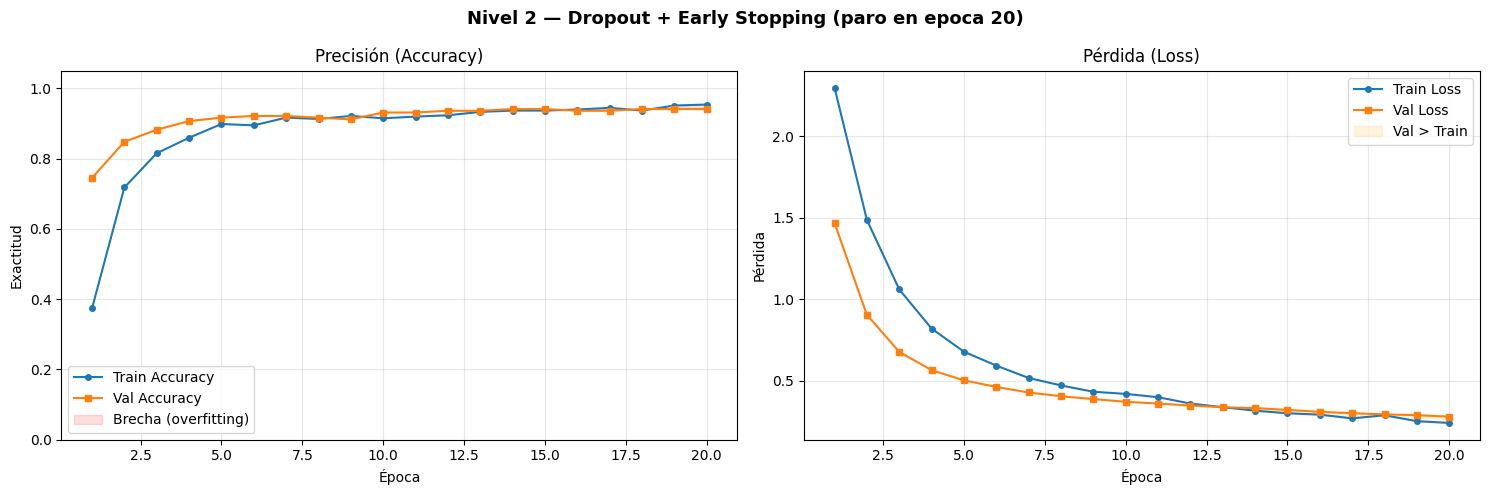

In [15]:
plot_curves(history_n2,
            f"Nivel 2 — Dropout + Early Stopping (paro en epoca {stopped_epoch_n2})",
            save_path=LOG_DIR / "n2_curvas.png")


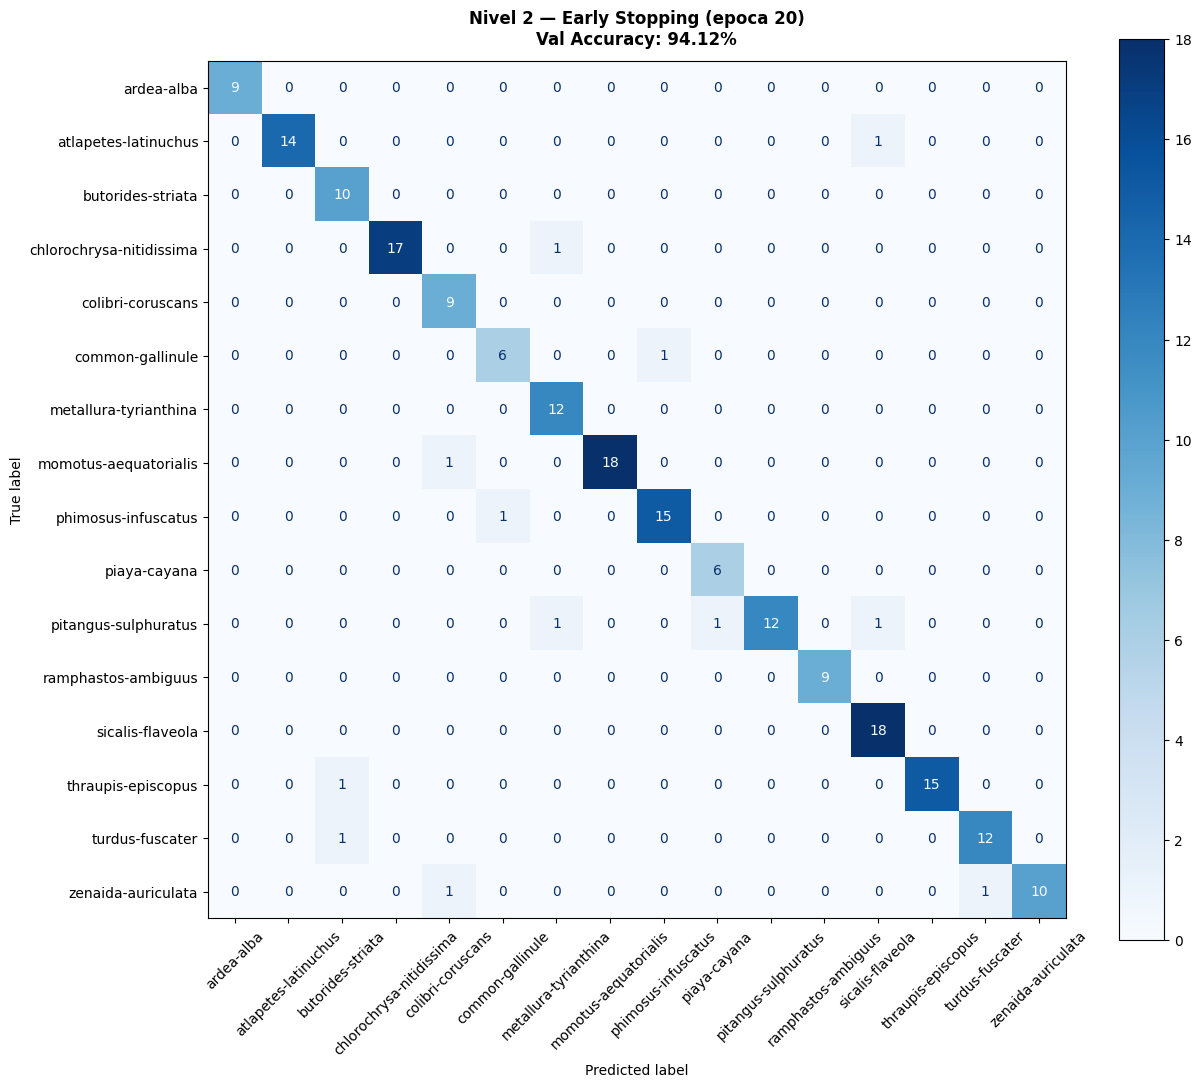

  NIVEL 2 — Resultado del Early Stopping
  Paro en epoca      : 20 / 20
  Val Acc N1         : 0.9461
  Val Acc N2 (mejor) : 0.9412
  Gap N1             : +0.0024
  Gap N2             : +0.0129

  -> El ES no se activo: el modelo siguio mejorando hasta el final.
     Considera aumentar NUM_EPOCHS para ver el efecto completo.


In [16]:
_, _, acc_n2 = plot_confusion_matrix(
    model_n2, val_loader, classes,
    f"Nivel 2 — Early Stopping (epoca {stopped_epoch_n2})",
    save_path=LOG_DIR / "n2_confusion.png"
)

gap_n1 = history_n1[-1]["train_acc"] - history_n1[-1]["val_acc"]
gap_n2 = history_n2[-1]["train_acc"] - history_n2[-1]["val_acc"]

print("=" * 52)
print("  NIVEL 2 — Resultado del Early Stopping")
print("=" * 52)
print(f"  Paro en epoca      : {stopped_epoch_n2} / {NUM_EPOCHS}")
print(f"  Val Acc N1         : {max(r['val_acc'] for r in history_n1):.4f}")
print(f"  Val Acc N2 (mejor) : {max(r['val_acc'] for r in history_n2):.4f}")
print(f"  Gap N1             : {gap_n1:+.4f}")
print(f"  Gap N2             : {gap_n2:+.4f}")
print("=" * 52)
print()
if stopped_epoch_n2 < NUM_EPOCHS:
    print(f"  -> El ES paro antes de las {NUM_EPOCHS} epocas.")
    print(f"     Esto evito que el modelo siguiera memorizando.")
else:
    print(f"  -> El ES no se activo: el modelo siguio mejorando hasta el final.")
    print(f"     Considera aumentar NUM_EPOCHS para ver el efecto completo.")


---
## Nivel 3 — LR Decay solo (ReduceLROnPlateau)

### ¿Qué es el LR Decay?

Si el modelo da zig-zags en las graficas, el paso de aprendizaje es demasiado grande.
`ReduceLROnPlateau` lo reduce automaticamente cuando `val_loss` se estanca:

```
LR inicial: 1e-3
  -> si val_loss no mejora en 3 epocas: LR = 1e-3 x 0.2 = 2e-4
  -> si sigue sin mejorar en 3 epocas: LR = 2e-4 x 0.2 = 4e-5
  -> minimo permitido: 1e-6
```

> En este nivel **no hay Early Stopping**: el modelo corre las `NUM_EPOCHS` completas.
> Asi vemos el efecto del LR Decay de forma aislada sobre las curvas.


In [5]:
# ── Nivel 3: Dropout + LR Decay (sin Early Stopping) ─────────────
PATIENCE_LR = 3    # epocas sin mejora antes de reducir LR
LR_FACTOR   = 0.2  # LR = LR * factor
MIN_LR      = 1e-6

model_n3  = build_base_model(num_classes, dropout=0.5)
optim_n3  = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_n3.parameters()), lr=LR
)
scheduler_n3 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optim_n3, mode="min", factor=LR_FACTOR,
    patience=PATIENCE_LR, min_lr=MIN_LR,
)

history_n3 = []

print("Entrenando Nivel 3 (Dropout + LR Decay, sin Early Stopping)...")
print(f"  patience_lr={PATIENCE_LR} | factor={LR_FACTOR} | min_lr={MIN_LR}")
print()
print(f"{'Epoca':>6}  {'Train Acc':>9}  {'Val Acc':>8}  {'Val Loss':>9}  {'LR actual':>11}")
print("-" * 52)

for epoch in range(1, NUM_EPOCHS + 1):
    tl, ta = run_epoch(model_n3, train_loader, criterion, optim_n3)
    vl, va = run_epoch(model_n3, val_loader,   criterion, None)
    scheduler_n3.step(vl)
    current_lr = optim_n3.param_groups[0]["lr"]

    history_n3.append({
        "epoch": epoch, "train_loss": round(tl,4), "train_acc": round(ta,4),
        "val_loss": round(vl,4), "val_acc": round(va,4), "lr": current_lr,
    })
    print(f"{epoch:>6}  {ta:>9.4f}  {va:>8.4f}  {vl:>9.4f}  {current_lr:>11.2e}")

print(f"\nOK Nivel 3 completado.")


Entrenando Nivel 3 (Dropout + LR Decay, sin Early Stopping)...
  patience_lr=3 | factor=0.2 | min_lr=1e-06

 Epoca  Train Acc   Val Acc   Val Loss    LR actual
----------------------------------------------------


NameError: name 'criterion' is not defined

In [ ]:
plot_curves(history_n3,
            "Nivel 3 — Dropout + LR Decay (sin Early Stopping)",
            save_path=LOG_DIR / "n3_curvas.png")

# Grafica adicional: evolucion del LR a lo largo de las epocas
lr_vals = [r["lr"] for r in history_n3]
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(range(1, len(lr_vals)+1), lr_vals, "o-", ms=4, color="steelblue")
ax.set_title("Evolucion del Learning Rate — Nivel 3", fontweight="bold")
ax.set_xlabel("Epoca"); ax.set_ylabel("LR")
ax.set_yscale("log"); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(LOG_DIR / "n3_lr_evolution.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
_, _, acc_n3 = plot_confusion_matrix(
    model_n3, val_loader, classes,
    "Nivel 3 — LR Decay (sin Early Stopping)",
    save_path=LOG_DIR / "n3_confusion.png"
)

gap_n3 = history_n3[-1]["train_acc"] - history_n3[-1]["val_acc"]
lr_changes = sum(1 for i in range(1, len(history_n3))
                 if history_n3[i]["lr"] < history_n3[i-1]["lr"])

print("=" * 52)
print("  NIVEL 3 — Resultado del LR Decay")
print("=" * 52)
print(f"  Veces que bajo el LR    : {lr_changes}")
print(f"  LR inicial              : {LR:.2e}")
print(f"  LR final                : {history_n3[-1]['lr']:.2e}")
print(f"  Val Acc N2 (mejor)      : {max(r['val_acc'] for r in history_n2):.4f}")
print(f"  Val Acc N3 (mejor)      : {max(r['val_acc'] for r in history_n3):.4f}")
print(f"  Gap N3                  : {gap_n3:+.4f}")
print("=" * 52)
print()
if lr_changes > 0:
    print(f"  -> El LR bajo {lr_changes} vez/veces durante el entrenamiento.")
    print(f"     Esto suavizo las curvas y permitio ajustes mas finos.")
else:
    print(f"  -> El LR nunca bajo: val_loss mejoro constantemente.")
    print(f"     El modelo puede haberse beneficiado de mas epocas.")


---
## Nivel 4 — Early Stopping + LR Decay combinados

Ahora aplicamos **las dos tecnicas juntas** sobre el modelo con Dropout.

- `ReduceLROnPlateau` suaviza el camino hacia el minimo.
- `Early Stopping` detiene el entrenamiento cuando ese minimo ya fue alcanzado.

> Este es el nivel mas completo. Compararemos su resultado contra los niveles
> anteriores para ver si la combinacion supera a cada tecnica por separado.


In [11]:
# ── Nivel 4: Dropout + Early Stopping + LR Decay ─────────────────
PATIENCE_ES4 = 5
PATIENCE_LR4 = 3
LR_FACTOR4   = 0.2
MIN_LR4      = 1e-6

model_n4  = build_base_model(num_classes, dropout=0.5)
optim_n4  = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_n4.parameters()), lr=LR
)
scheduler_n4 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optim_n4, mode="min", factor=LR_FACTOR4,
    patience=PATIENCE_LR4, min_lr=MIN_LR4,
)

history_n4    = []
best_val_loss = float("inf")
best_weights  = None
es_counter    = 0
stopped_epoch_n4 = NUM_EPOCHS

print("Entrenando Nivel 4 (Dropout + Early Stopping + LR Decay)...")
print(f"  patience_es={PATIENCE_ES4} | patience_lr={PATIENCE_LR4} | factor={LR_FACTOR4}")
print()
print(f"{'Epoca':>6}  {'Train Acc':>9}  {'Val Acc':>8}  {'Val Loss':>9}  {'LR':>10}  {'ES':>6}")
print("-" * 56)

for epoch in range(1, NUM_EPOCHS + 1):
    tl, ta = run_epoch(model_n4, train_loader, criterion, optim_n4)
    vl, va = run_epoch(model_n4, val_loader,   criterion, None)
    scheduler_n4.step(vl)
    current_lr = optim_n4.param_groups[0]["lr"]

    if vl < best_val_loss:
        best_val_loss = vl
        best_weights  = copy.deepcopy(model_n4.state_dict())
        es_counter    = 0
        es_marker     = "[*]"
    else:
        es_counter += 1
        es_marker   = f"{es_counter}/{PATIENCE_ES4}"

    history_n4.append({
        "epoch": epoch, "train_loss": round(tl,4), "train_acc": round(ta,4),
        "val_loss": round(vl,4), "val_acc": round(va,4), "lr": current_lr,
    })
    print(f"{epoch:>6}  {ta:>9.4f}  {va:>8.4f}  {vl:>9.4f}  {current_lr:>10.2e}  {es_marker:>6}")

    if es_counter >= PATIENCE_ES4:
        stopped_epoch_n4 = epoch
        print(f"\n  [STOP] Early Stopping en epoca {epoch}.")
        model_n4.load_state_dict(best_weights)
        break

if stopped_epoch_n4 == NUM_EPOCHS:
    print(f"\n  [i] Completo las {NUM_EPOCHS} epocas sin activar Early Stopping.")

print(f"\nOK Nivel 4 completado. Parado en epoca {stopped_epoch_n4}.")


Entrenando Nivel 4 (Dropout + Early Stopping + LR Decay)...
  patience_es=5 | patience_lr=3 | factor=0.2

 Epoca  Train Acc   Val Acc   Val Loss          LR      ES
--------------------------------------------------------


/home/walter/miniconda3/envs/aves/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


     1     0.3671    0.7843     1.4136    1.00e-03     [*]
     2     0.7304    0.8578     0.8654    1.00e-03     [*]
     3     0.8222    0.8676     0.6556    1.00e-03     [*]
     4     0.8681    0.8775     0.5581    1.00e-03     [*]
     5     0.8681    0.8775     0.5031    1.00e-03     [*]
     6     0.9044    0.8873     0.4697    1.00e-03     [*]
     7     0.8939    0.8922     0.4369    1.00e-03     [*]
     8     0.9226    0.9167     0.4116    1.00e-03     [*]
     9     0.9130    0.9216     0.3935    1.00e-03     [*]
    10     0.9140    0.9363     0.3708    1.00e-03     [*]
    11     0.9273    0.9265     0.3552    1.00e-03     [*]
    12     0.9331    0.9265     0.3438    1.00e-03     [*]
    13     0.9273    0.9363     0.3327    1.00e-03     [*]
    14     0.9426    0.9412     0.3181    1.00e-03     [*]
    15     0.9398    0.9412     0.3045    1.00e-03     [*]
    16     0.9379    0.9510     0.2905    1.00e-03     [*]
    17     0.9388    0.9510     0.2815    1.00e-03     [

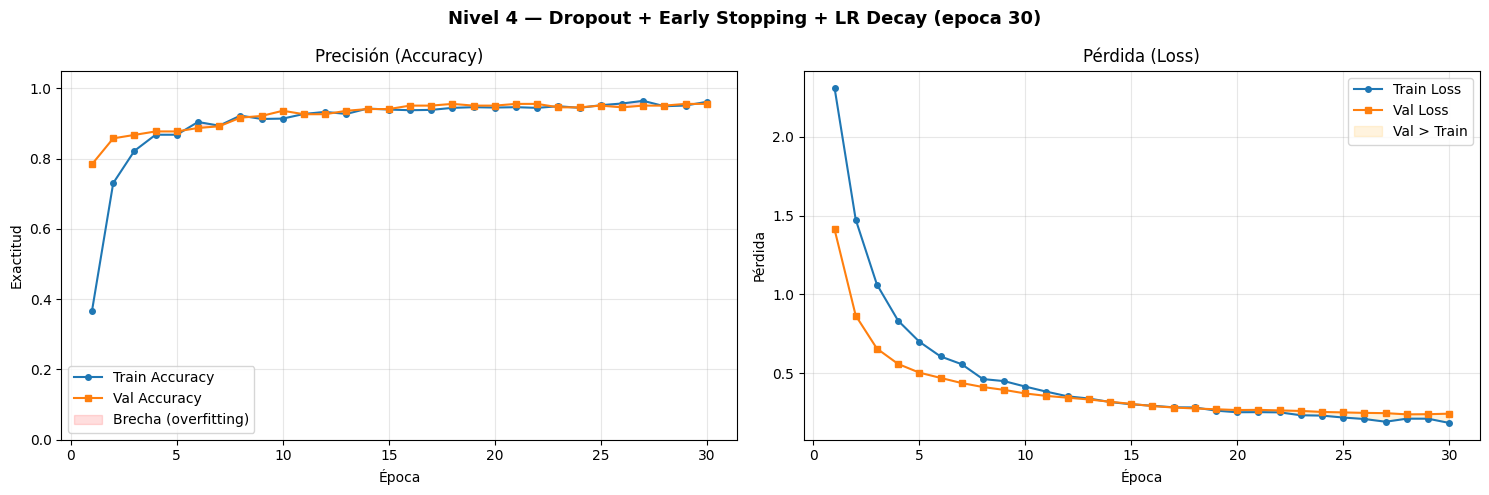

In [12]:
plot_curves(history_n4,
            f"Nivel 4 — Dropout + Early Stopping + LR Decay (epoca {stopped_epoch_n4})",
            save_path=LOG_DIR / "n4_curvas.png")


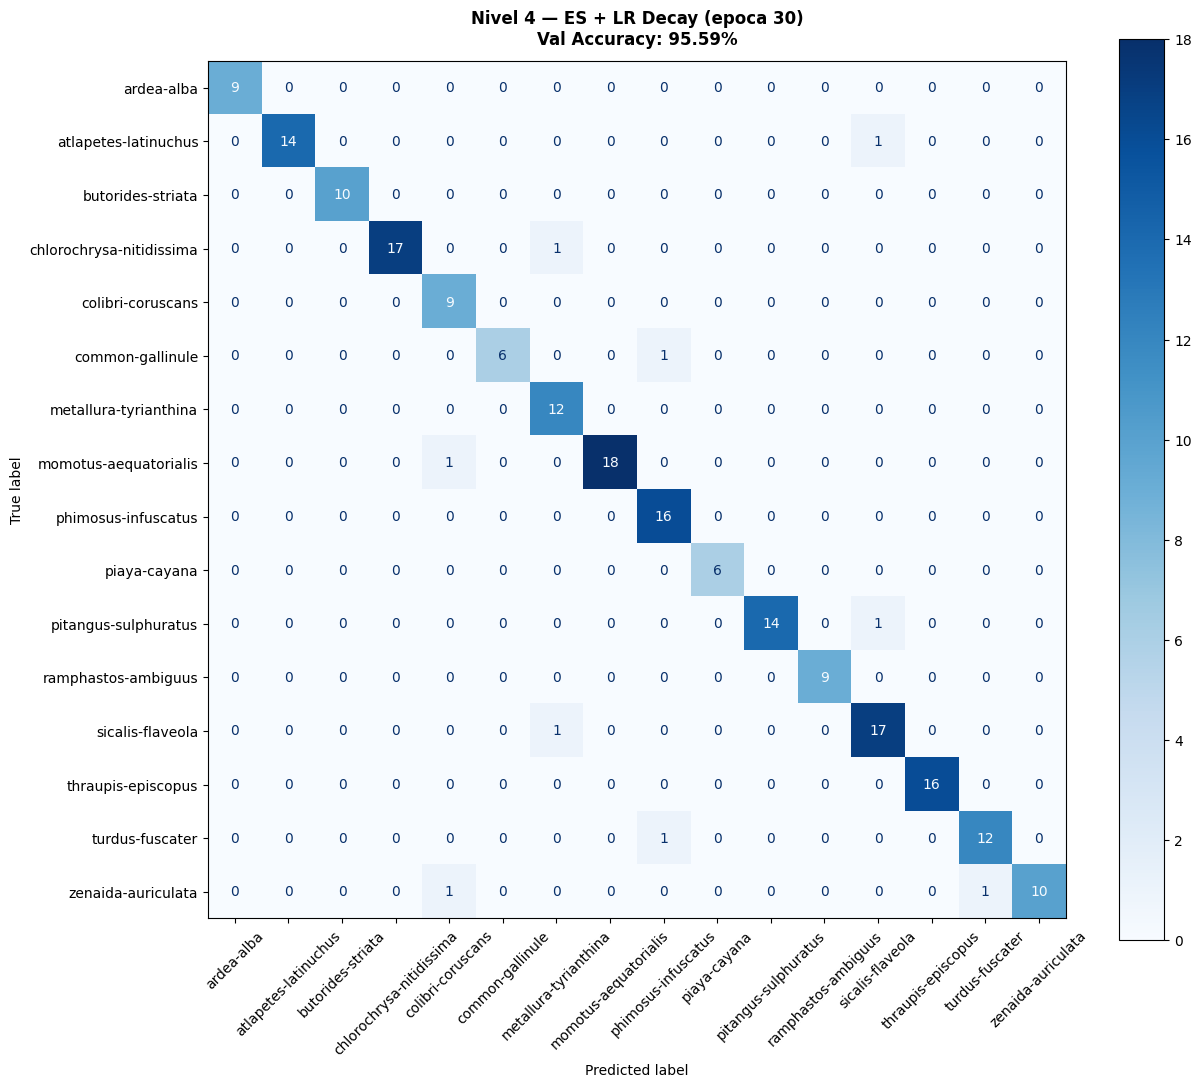

In [13]:
_, _, acc_n4 = plot_confusion_matrix(
    model_n4, val_loader, classes,
    f"Nivel 4 — ES + LR Decay (epoca {stopped_epoch_n4})",
    save_path=LOG_DIR / "n4_confusion.png"
)


---
## Nivel 5 — Comparativa Global

Superponemos las curvas `val_accuracy` de todos los niveles para ver
el impacto acumulativo de cada tecnica de forma directa.


NameError: name 'history_n1' is not defined

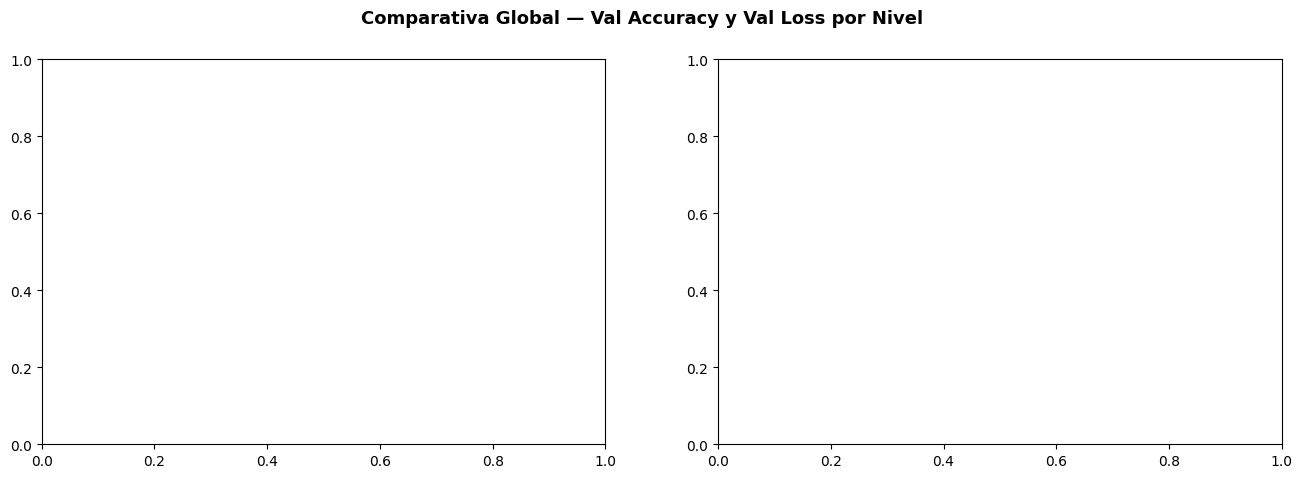

In [14]:
# ── Curvas comparativas superpuestas ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Comparativa Global — Val Accuracy y Val Loss por Nivel",
             fontsize=13, fontweight="bold")

configs = [
    (history_n0,  "N0 — Base",             "o--", "steelblue"),
    (history_n1,  "N1 — Dropout",          "s--", "darkorange"),
    (history_n2,  "N2 — Early Stop",        "^-",  "mediumpurple"),
    (history_n3,  "N3 — LR Decay",          "D-",  "seagreen"),
    (history_n4,  "N4 — ES + LR Decay",     "P-",  "crimson"),
]

for hist, label, style, color in configs:
    epochs = [r["epoch"]    for r in hist]
    v_acc  = [r["val_acc"]  for r in hist]
    v_loss = [r["val_loss"] for r in hist]
    axes[0].plot(epochs, v_acc,  style, ms=4, label=label, color=color)
    axes[1].plot(epochs, v_loss, style, ms=4, label=label, color=color)

axes[0].set_title("Val Accuracy")
axes[0].set_xlabel("Epoca"); axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1.05); axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

axes[1].set_title("Val Loss")
axes[1].set_xlabel("Epoca"); axes[1].set_ylabel("Loss")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(LOG_DIR / "n5_comparativa_global.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Preguntas del Taller — Respuestas con Evidencia

Ahora que cada tecnica se probó por separado, las respuestas tienen evidencia clara.


In [ ]:
# PREGUNTA 1: ¿El Dropout solo mejoró el gap?
gap_n0 = history_n0[-1]["train_acc"] - history_n0[-1]["val_acc"]
gap_n1 = history_n1[-1]["train_acc"] - history_n1[-1]["val_acc"]
gap_n2 = history_n2[-1]["train_acc"] - history_n2[-1]["val_acc"]
gap_n3 = history_n3[-1]["train_acc"] - history_n3[-1]["val_acc"]
gap_n4 = history_n4[-1]["train_acc"] - history_n4[-1]["val_acc"]

print("=" * 55)
print("  PREGUNTA 1 — Con Dropout solo, ¿mejoro el gap?")
print("=" * 55)
print(f"  Gap N0 (base)        : {gap_n0:+.4f}")
print(f"  Gap N1 (Dropout)     : {gap_n1:+.4f}  "
      f"{'-> MEJORO' if gap_n1 < gap_n0 else '-> No mejoro significativamente'}")
print("=" * 55)


In [ ]:
# PREGUNTA 2: ¿Qué aves siguen confundiéndose en el mejor modelo?
from collections import Counter

# Determinar el mejor modelo por val_acc
niveles_eval = [
    ("N0", history_n0, model_n0),
    ("N1", history_n1, model_n1),
    ("N2", history_n2, model_n2),
    ("N3", history_n3, model_n3),
    ("N4", history_n4, model_n4),
]
mejor_nombre, mejor_hist, mejor_model = max(
    niveles_eval, key=lambda x: max(r["val_acc"] for r in x[1])
)

all_preds, all_labels = [], []
mejor_model.eval()
with torch.no_grad():
    for imgs, labels in val_loader:
        preds = mejor_model(imgs.to(device)).argmax(1)
        all_preds.append(preds.cpu()); all_labels.append(labels)

y_pred = torch.cat(all_preds).numpy()
y_true = torch.cat(all_labels).numpy()

report_dict = classification_report(y_true, y_pred, target_names=classes, output_dict=True)
f1_scores   = {cls: report_dict[cls]["f1-score"] for cls in classes}

cm    = confusion_matrix(y_true, y_pred)
cm_nd = cm.copy(); import numpy as np; np.fill_diagonal(cm_nd, 0)
errores = sorted(
    [(cm_nd[i,j], classes[i], classes[j])
     for i in range(len(classes)) for j in range(len(classes))
     if i != j and cm_nd[i,j] > 0],
    reverse=True
)

print("=" * 60)
print(f"  PREGUNTA 2 — Mejor modelo: {mejor_nombre}")
print(f"  Aves con F1 < 0.70 (mas dificiles):")
print("=" * 60)
bajas = [(c, f1_scores[c]) for c in classes if f1_scores[c] < 0.70]
bajas.sort(key=lambda x: x[1])
if bajas:
    for cls, f1 in bajas:
        print(f"  {cls:<35}  F1 = {f1:.3f}")
else:
    print("  Todas las clases tienen F1 >= 0.70")
print()
print("  Confusiones mas frecuentes:")
for count, real, pred in errores[:5]:
    if count > 0:
        print(f"    {real} -> {pred}  ({count} casos)")
print("=" * 60)


In [ ]:
# ════════════════════════════════════════════════════════════════
#  PREGUNTA 3: ¿Mejor 100% train / 70% val, o 85% en ambos?
# ════════════════════════════════════════════════════════════════
escenario_A_train = 1.00; escenario_A_val = 0.70
escenario_B_train = 0.85; escenario_B_val = 0.85

gap_A = escenario_A_train - escenario_A_val
gap_B = escenario_B_train - escenario_B_val

print("━" * 62)
print("  PREGUNTA 3 — ¿100/70 o 85/85? La clave es la consistencia")
print("━" * 62)
print()
print(f"  Escenario A → Train: {escenario_A_train:.0%} | Val: {escenario_A_val:.0%} | Gap: {gap_A:.0%}")
print(f"  Escenario B → Train: {escenario_B_train:.0%} | Val: {escenario_B_val:.0%} | Gap: {gap_B:.0%}")
print()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (ta, va, title) in zip(axes, [
    (escenario_A_train, escenario_A_val, "A — 100% train / 70% val\n(Overfitting)"),
    (escenario_B_train, escenario_B_val, "B — 85% train / 85% val\n(Generalización [OK])"),
]):
    bars = ax.bar(["Train", "Validación"], [ta, va],
                  color=["steelblue", "salmon" if abs(ta-va) > 0.1 else "seagreen"])
    ax.set_ylim(0, 1.1)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel("Accuracy")
    for bar, val in zip(bars, [ta, va]):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                f"{val:.0%}", ha="center", fontsize=12, fontweight="bold")
    ax.axhline(y=0.85, color="gray", linestyle="--", alpha=0.5)
    ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(LOG_DIR / "pregunta3_comparativa.png", dpi=150, bbox_inches="tight")
plt.show()

print("  RESPUESTA:")
print("  El Escenario B (85%/85%) es MEJOR para el mundo real.")
print()
print("  El 100% en entrenamiento del Escenario A indica que el modelo")
print("  MEMORIZÓ el dataset en vez de aprender patrones generales.")
print("  Cuando llega una imagen nueva, falla porque nunca 'vio' esa")
print("  variación antes. En campo, ese 30% de gap se traduce en errores")
print("  reales que afectan estudios de biodiversidad.")
print()
print("  El 85%/85% demuestra que el modelo GENERALIZA: lo que aprendió")
print("  con imágenes de entrenamiento sirve igual de bien para imágenes")
print("  nuevas. Esto es lo que busca Merlin y cualquier app de campo.")
print()
print("  Regla práctica: un gap < 5% entre train y val es señal de")
print("  un modelo bien regularizado y listo para despliegue.")


---
## Nivel 5 — Todas las Técnicas + Guardado de Checkpoints

Este es el nivel de producción: aplicamos **Dropout + Early Stopping + LR Decay**
y además guardamos el estado completo del modelo en dos archivos:

| Archivo | Contenido |
|---------|-----------|
| `best.pth` | Pesos de la época con mejor `val_loss` — el que usaremos para evaluar |
| `last.pth` | Pesos al finalizar (o al parar) — útil para reanudar entrenamiento |

### Formato del checkpoint

```python
{
  "epoch":                int,    # ultima epoca completada
  "model_name":           str,    # "mobilenet_v3_small"
  "model_state_dict":     dict,   # pesos del modelo
  "optimizer_state_dict": dict,   # estado del optimizador (para reanudar)
  "scheduler_state_dict": dict,   # estado del scheduler
  "best_val_acc":         float,  # mejor val_acc vista hasta ahora
  "val_accuracy":         float,  # val_acc de ESTA epoca
  "val_loss":             float,  # val_loss de ESTA epoca
  "classes":              list,   # nombres de las clases
  "class_to_idx":         dict,   # mapeo clase → indice
  "history":              list,   # historial completo de epocas
}
```

> El checkpoint incluye `optimizer_state_dict` y `scheduler_state_dict`
> para poder **reanudar el entrenamiento** desde el punto exacto donde se detuvo
> sin perder el momentum del optimizador ni el estado del scheduler.


In [16]:
# ── Nivel 5: Dropout + Early Stopping + LR Decay + Checkpoints ───

PATIENCE_ES5 = 5
PATIENCE_LR5 = 3
LR_FACTOR5   = 0.2
MIN_LR5      = 1e-6

model_n5  = build_base_model(num_classes, dropout=0.5)
optim_n5  = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_n5.parameters()), lr=LR
)
sched_n5  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optim_n5, mode="min", factor=LR_FACTOR5,
    patience=PATIENCE_LR5, min_lr=MIN_LR5, 
)

history_n5    = []
best_val_loss = float("inf")
best_val_acc  = 0.0
es_counter    = 0
stopped_epoch = NUM_EPOCHS

best_ckpt_path = CKPT_DIR / "best.pth"
last_ckpt_path = CKPT_DIR / "last.pth"

print("Entrenando Nivel 5 (todas las tecnicas + checkpoints)...")
print(f"  patience_es={PATIENCE_ES5} | patience_lr={PATIENCE_LR5} | factor={LR_FACTOR5}")
print(f"  best.pth → {best_ckpt_path}")
print(f"  last.pth → {last_ckpt_path}")
print()
print(f"{'Epoca':>6}  {'Train Acc':>9}  {'Val Acc':>8}  {'Val Loss':>9}  {'LR':>10}  {'ES':>6}  {'Ckpt':>6}")
print("-" * 65)

for epoch in range(1, NUM_EPOCHS + 1):
    tl, ta = run_epoch(model_n5, train_loader, criterion, optim_n5)
    vl, va = run_epoch(model_n5, val_loader,   criterion, None)
    sched_n5.step(vl)
    current_lr = optim_n5.param_groups[0]["lr"]

    # ── Construir checkpoint base ─────────────────────────────────
    ckpt = {
        "epoch":                epoch,
        "model_name":           "mobilenet_v3_small",
        "model_state_dict":     model_n5.state_dict(),
        "optimizer_state_dict": optim_n5.state_dict(),
        "scheduler_state_dict": sched_n5.state_dict(),
        "best_val_acc":         best_val_acc,
        "val_accuracy":         round(va, 4),
        "val_loss":             round(vl, 4),
        "classes":              classes,
        "class_to_idx":         train_ds.class_to_idx,
        "history":              history_n5 + [{   # incluye la epoca actual
            "epoch": epoch, "train_loss": round(tl,4), "train_acc": round(ta,4),
            "val_loss": round(vl,4), "val_acc": round(va,4), "lr": current_lr,
        }],
    }

    # ── Siempre guardar last.pth ──────────────────────────────────
    torch.save(ckpt, last_ckpt_path)
    ckpt_marker = "last"

    # ── Early Stopping + guardar best.pth si mejora ───────────────
    if vl < best_val_loss:
        best_val_loss = vl
        best_val_acc  = va
        ckpt["best_val_acc"] = va          # actualizar en el dict
        torch.save(ckpt, best_ckpt_path)
        es_counter  = 0
        es_marker   = "[*]"
        ckpt_marker = "best+last"
    else:
        es_counter += 1
        es_marker   = f"{es_counter}/{PATIENCE_ES5}"

    history_n5.append({
        "epoch": epoch, "train_loss": round(tl,4), "train_acc": round(ta,4),
        "val_loss": round(vl,4), "val_acc": round(va,4), "lr": current_lr,
    })

    print(f"{epoch:>6}  {ta:>9.4f}  {va:>8.4f}  {vl:>9.4f}  "
          f"{current_lr:>10.2e}  {es_marker:>6}  {ckpt_marker}")

    if es_counter >= PATIENCE_ES5:
        stopped_epoch = epoch
        print(f"\n  [STOP] Early Stopping en epoca {epoch}.")
        print(f"         best.pth contiene los pesos de la mejor epoca.")
        break

if stopped_epoch == NUM_EPOCHS:
    print(f"\n  [i] Completo las {NUM_EPOCHS} epocas sin activar Early Stopping.")

print(f"\nOK Nivel 5 completado.")
print(f"  Mejor val_acc : {best_val_acc:.4f}")
print(f"  Paro en epoca : {stopped_epoch}")


Entrenando Nivel 5 (todas las tecnicas + checkpoints)...
  patience_es=5 | patience_lr=3 | factor=0.2
  best.pth → ../src/models/checkpoints/pro/best.pth
  last.pth → ../src/models/checkpoints/pro/last.pth

 Epoca  Train Acc   Val Acc   Val Loss          LR      ES    Ckpt
-----------------------------------------------------------------


/home/walter/miniconda3/envs/aves/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


     1     0.3174    0.7745     1.4485    1.00e-03     [*]  best+last
     2     0.7266    0.8431     0.8805    1.00e-03     [*]  best+last
     3     0.8308    0.8627     0.6661    1.00e-03     [*]  best+last
     4     0.8700    0.8824     0.5629    1.00e-03     [*]  best+last
     5     0.8776    0.9020     0.5040    1.00e-03     [*]  best+last
     6     0.8881    0.9118     0.4622    1.00e-03     [*]  best+last
     7     0.8996    0.9118     0.4334    1.00e-03     [*]  best+last
     8     0.9092    0.9118     0.4119    1.00e-03     [*]  best+last
     9     0.9159    0.9118     0.3932    1.00e-03     [*]  best+last
    10     0.9140    0.9216     0.3760    1.00e-03     [*]  best+last
    11     0.9321    0.9314     0.3615    1.00e-03     [*]  best+last
    12     0.9245    0.9314     0.3499    1.00e-03     [*]  best+last
    13     0.9340    0.9314     0.3329    1.00e-03     [*]  best+last
    14     0.9350    0.9412     0.3177    1.00e-03     [*]  best+last
    15     0.9331   

---
## Tabla Comparativa Final

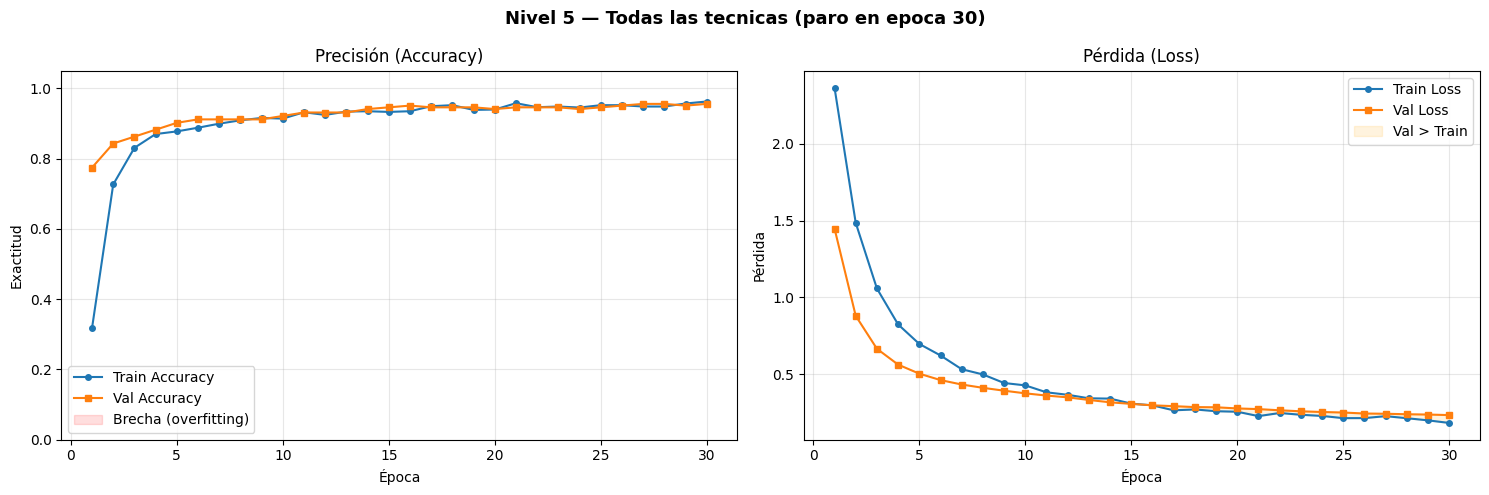

In [17]:
plot_curves(history_n5,
            f"Nivel 5 — Todas las tecnicas (paro en epoca {stopped_epoch})",
            save_path=LOG_DIR / "n5_curvas.png")


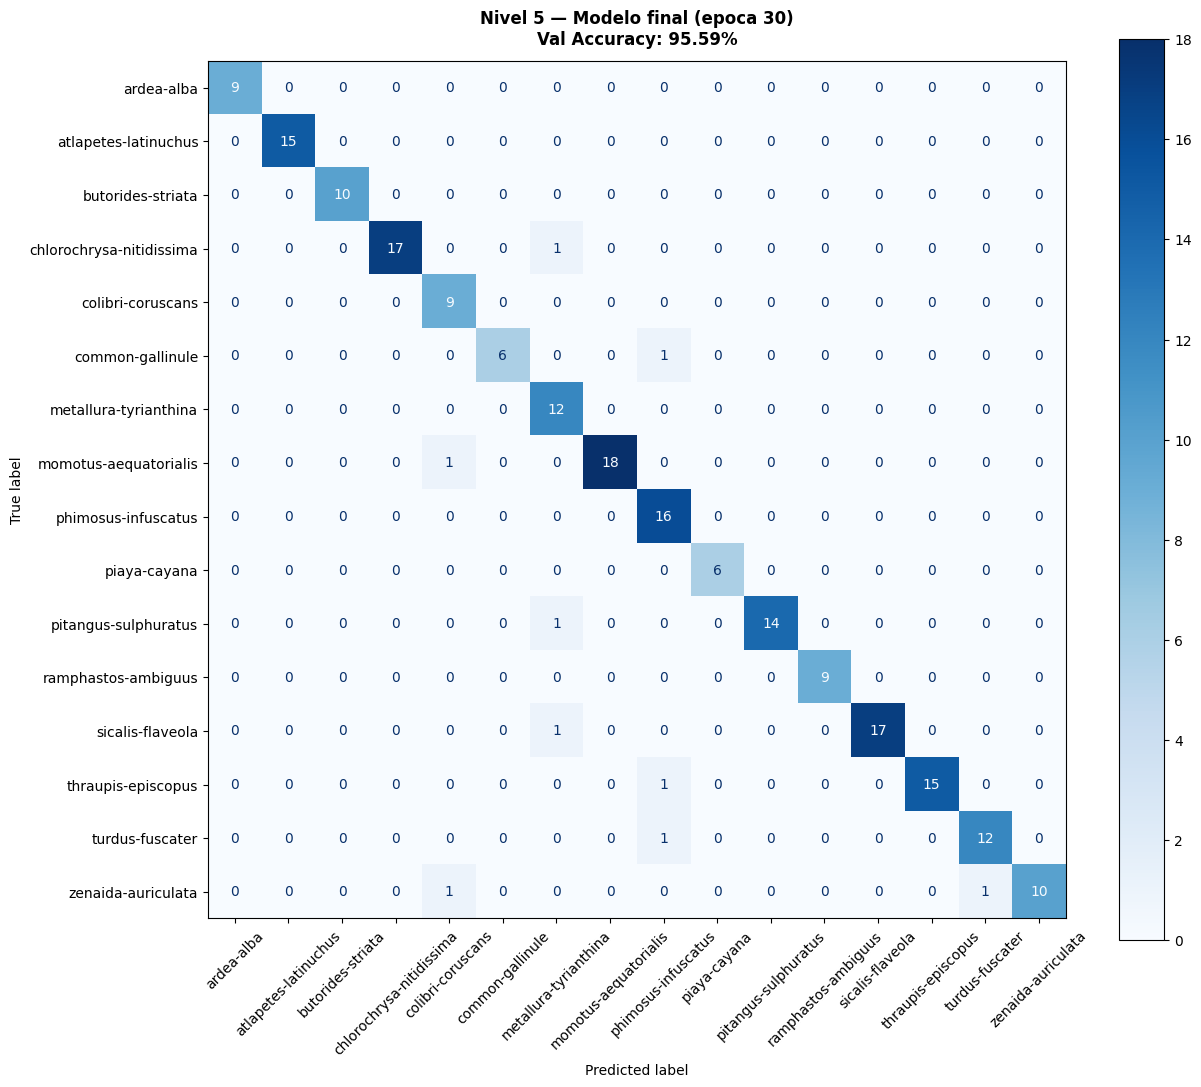

In [18]:
_, _, acc_n5 = plot_confusion_matrix(
    model_n5, val_loader, classes,
    f"Nivel 5 — Modelo final (epoca {stopped_epoch})",
    save_path=LOG_DIR / "n5_confusion.png"
)


In [19]:
# ── Verificar que los checkpoints son legibles ────────────────────
print("Verificando checkpoints guardados...")
print()

for label, path in [("best.pth", best_ckpt_path), ("last.pth", last_ckpt_path)]:
    if not path.exists():
        print(f"  [!] {label} NO encontrado en {path}")
        continue

    ckpt_loaded = torch.load(path, map_location="cpu")
    size_mb     = path.stat().st_size / 1024 / 1024

    print(f"  {label}")
    print(f"    Ruta          : {path}")
    print(f"    Tamano        : {size_mb:.1f} MB")
    print(f"    Epoca         : {ckpt_loaded['epoch']}")
    print(f"    Val Acc       : {ckpt_loaded['val_accuracy']:.4f}")
    print(f"    Best Val Acc  : {ckpt_loaded['best_val_acc']:.4f}")
    print(f"    Clases        : {len(ckpt_loaded['classes'])} ({ckpt_loaded['classes'][:3]}...)")
    print(f"    Epocas en hist: {len(ckpt_loaded['history'])}")
    print()

print("Para cargar el mejor modelo en el notebook de evaluacion:")
print()
print('  ckpt  = torch.load("../src/models/checkpoints/pro/best.pth")')
print('  model = build_base_model(len(ckpt["classes"]), dropout=0.5)')
print('  model.load_state_dict(ckpt["model_state_dict"])')
print('  model.eval()')


Verificando checkpoints guardados...

  best.pth
    Ruta          : ../src/models/checkpoints/pro/best.pth
    Tamano        : 6.1 MB
    Epoca         : 30
    Val Acc       : 0.9559
    Best Val Acc  : 0.9559
    Clases        : 16 (['ardea-alba', 'atlapetes-latinuchus', 'butorides-striata']...)
    Epocas en hist: 30

  last.pth
    Ruta          : ../src/models/checkpoints/pro/last.pth
    Tamano        : 6.1 MB
    Epoca         : 30
    Val Acc       : 0.9559
    Best Val Acc  : 0.9510
    Clases        : 16 (['ardea-alba', 'atlapetes-latinuchus', 'butorides-striata']...)
    Epocas en hist: 30

Para cargar el mejor modelo en el notebook de evaluacion:

  ckpt  = torch.load("../src/models/checkpoints/pro/best.pth")
  model = build_base_model(len(ckpt["classes"]), dropout=0.5)
  model.load_state_dict(ckpt["model_state_dict"])
  model.eval()


---
## Resumen Final del Taller

In [ ]:
# ── Tabla comparativa con los 6 niveles ──────────────────────────
def best_val(hist):
    return max(r["val_acc"] for r in hist)

def final_gap(hist):
    r = hist[-1]
    return r["train_acc"] - r["val_acc"]

niveles = [
    ("N0 — Base",          history_n0,  "Sin tecnicas",           "—"),
    ("N1 — Dropout",       history_n1,  "Dropout 50%",            "—"),
    ("N2+3 — Drop+ES+LR",  history_n23, "Drop+ES+LRdecay",        "—"),
    ("N5 — Todas+Ckpts",   history_n5,  "Drop+ES+LR+Checkpoints", "best.pth / last.pth"),
]

ref_acc = best_val(history_n0)

print("=" * 82)
print("  TABLA COMPARATIVA FINAL DEL TALLER")
print("=" * 82)
print(f"  {'Nivel':<24}  {'Tecnica':<24}  {'Epocas':>6}  "
      f"{'Best Val':>8}  {'Gap':>7}  {'vs Base':>8}")
print("-" * 82)

for nombre, hist, tecnica, ckpt_label in niveles:
    epocas = hist[-1]["epoch"]
    bva    = best_val(hist)
    gap    = final_gap(hist)
    mejora = bva - ref_acc
    vs     = "  <- base" if nombre.startswith("N0") else f"  {mejora:+.4f}"
    print(f"  {nombre:<24}  {tecnica:<24}  {epocas:>6}  {bva:>8.4f}  {gap:>+7.4f}{vs}")

print("=" * 82)
print()

mejor = max(niveles, key=lambda x: best_val(x[1]))
print(f"  Mejor nivel    : {mejor[0]}")
print(f"  Mejor val_acc  : {best_val(mejor[1]):.4f}")
print(f"  Ganancia total : {best_val(mejor[1]) - ref_acc:+.4f} respecto a la linea base")
print()
print("  Checkpoints del nivel final:")
print(f"    best.pth → {best_ckpt_path}")
print(f"    last.pth → {last_ckpt_path}")
print()
print("  Siguiente paso: usar best.pth en el notebook de evaluacion")
print("  para comparar el modelo pro vs la linea base lado a lado.")
